# Statistical testing to identify differentially regulated proteins

_In this tutorial we explore statistical testing in quantitative proteomics._

The focus is on how missing values influence statistical inference and how they affect differential protein analysis.

We will use the same dataset as in the 05_Complexes_and_PTMs tutorial.

#### Goals of this notebook:

* Explore missing values in the dataset
* Understand how missing values influence statistical testing
* Perform differential protein analysis
* Interpret statistical result


#### Description of the data:

Quantitative proteomics data usually comes from bottom-up LC-MS (liquid chromatography mass spectrometry) experiments, where the proteins are digested into peptides prior to data acquisition. This means that we have to go from the peptide to the protein level.

As data example, you will use the experimental data from an investigation of molecular signaling networks activated during muscle formation by Christina Erika Hagensen et. al (manuscript in preparation). The study is started with human satellite cells. These are resting muscle cells, that can be activated and developed into mature muscle cells e.g. when muscles are damaged. When activated, the satellite cells divide and produce myoblasts that further proliferate and fuse into myotubes which later mature into myofibers. This process is driven by signalling events leading to the necessary changes in  the transcriptional programme, cell behavior and morphology. 

The samples were measured in triplicates for each of the 6 times points as given in the following picture.

![Muscle time study](Muscle_Time_study.JPG)


### General instructions

You will go through the different cells of the workflow below. Execute the cells by pressing "shift-enter" or clicking on the triangle on the top.

For giving the answers to the questions below, double-click on the Jupyter cell, and add them at the given position.

👨‍💻 Start with running the following cell (only once)

In [5]:
# Some preparations like installing and loading libraries. Run only once
# install.packages("BiocManager")
# BiocManager::install(c("PolySTest","gplots","ggplot2","lattice","limma"))
library(gplots)
library(ggplot2)
library(lattice)
library(limma)
library(PolySTest)
options(repr.plot.width=12, repr.plot.height=8)

### Load data table

👨‍💻 Load the expression profiles of relative protein abundance levels

This data structure is the result of a data analysis workflow with Proteome Discoverer to extract the quantitative changes from hundreds of thousands of mass spectra, each of them providing information about a a protein.


In [6]:
# Read the protein table
protein_table <- read.csv("MuscleDiffDataProteins.csv", header=TRUE, row.names=1)

dim(protein_table)
head(protein_table)

[1] 6863   23

,Protein.Name,Gene.Name,Alt.Gene.Name,Total.identified.peptides,Total.quantified.peptides,D.1a,D.1b,D.1c,D0a,D0b,⋯,D1c,D2a,D2b,D2c,D3a,D3b,D3c,D4a,D4b,D4c
,<chr>,<chr>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A0A0B4J2D5|P0DPI2,"Glutamine amidotransferase-like class 1 domain-containing protein 3B, mitochondrial (Keio novel protein-I) (KNP-I) (Protein GT335) (Protein HES1)",GATD3B,GATD3A,12,12,-0.5251179,-0.51671502,-0.55209088,-0.36055439,-0.3493686077,⋯,-0.08273252,0.262086486,0.178264929,0.169548186,0.33013725,0.28260496,0.320238580,0.47500193,0.419851362,0.40052855
A0A0B4J2F2,Probable serine/threonine-protein kinase SIK1B (EC 2.7.11.1) (Salt-inducible kinase 1B),SIK1B,,6,5,0.1475126,0.13898200,-0.03150727,0.09633941,0.0677888023,⋯,-0.39308133,0.076310701,0.117832285,0.173337890,0.11296450,0.13732678,0.111705177,0.06121677,-0.003782580,0.03244185
A0A0U1RRE5,Negative regulator of P-body association (P-body dissociating protein) (Protein NoBody),NBDY,,2,2,-0.1878377,-0.17238270,-0.20505666,-0.04632349,0.0024007144,⋯,-0.08752390,0.082091197,0.032143688,0.109729671,0.13106619,0.12683730,0.040264570,0.15638549,0.007111036,0.13939663
A0A0U1RRL7,Protein MMP24OS (MMP24 opposite strand),MMP24OS,,2,2,-0.1399078,-0.02487446,-0.16507700,-0.06785273,0.0002731251,⋯,0.09755882,0.078639841,-0.007375918,0.007836292,0.12332700,-0.07456174,0.004563446,0.01389115,-0.030087983,-0.10529060
A0A1B0GTQ4,Protein myomixer (Microprotein inducer of fusion) (Protein minion) (hMINION),MYMX,,3,3,-1.6246881,-1.61525806,-1.20200581,-0.31159556,-0.5495690910,⋯,0.75861089,1.188720278,1.262698679,1.227183156,0.70041151,0.38595500,0.449429424,-0.73119678,-0.758072653,-0.65731685
A0AVT1,Ubiquitin-like modifier-activating enzyme 6 (Ubiquitin-activating enzyme 6) (EC 6.2.1.45) (Monocyte protein 4) (MOP-4) (Ubiquitin-activating enzyme E1-like protein 2) (E1-L2),UBA6,,33,26,0.1337052,0.09993774,0.19111442,0.05409326,0.0468627433,⋯,0.14574681,0.009562295,0.026301174,-0.019293673,-0.04565498,-0.13527095,-0.139548734,-0.06149500,-0.218080801,-0.19508473


## Understanding the data structure of the protein table

#### Add your answers here
(double-click here to edit the cell)

❔ Question I:  <ins>How many proteins does the data set contain?. </ins>

_Answer_

❔ Question II:  <ins>Which columns denote the different time points and replicates?</ins>

_Answer_

❔ Question II:  <ins>The first column (before "Protein.Name") shows uniprot accession numbers. What are these and why are they important?</ins>

_Answer_




## Exploring Missing Values

Mass-spectrometry proteomics datasets often contain missing values. In our case we have an experiment that merged several multi-plexed TMT experiments. Then the number of missing values is typically lower than in label-free experiments because multiple samples are measured together in the same LC-MS run. However, missing measurements can still occur, particularly when comparing different TMT runs.

👨‍💻 In the following, we explore how missing values are distributed in the dataset.

[1] 3271

Day_-1A Day_-1B Day_-1C  Day_0A  Day_0B  Day_0C  Day_1A  Day_1B  Day_1C  Day_2A 
    154     154     209     154     154     210     154     154     209     154 
 Day_2B  Day_2C  Day_3A  Day_3B  Day_3C  Day_4A  Day_4B  Day_4C 
    209     209     154     210     209     154     211     209

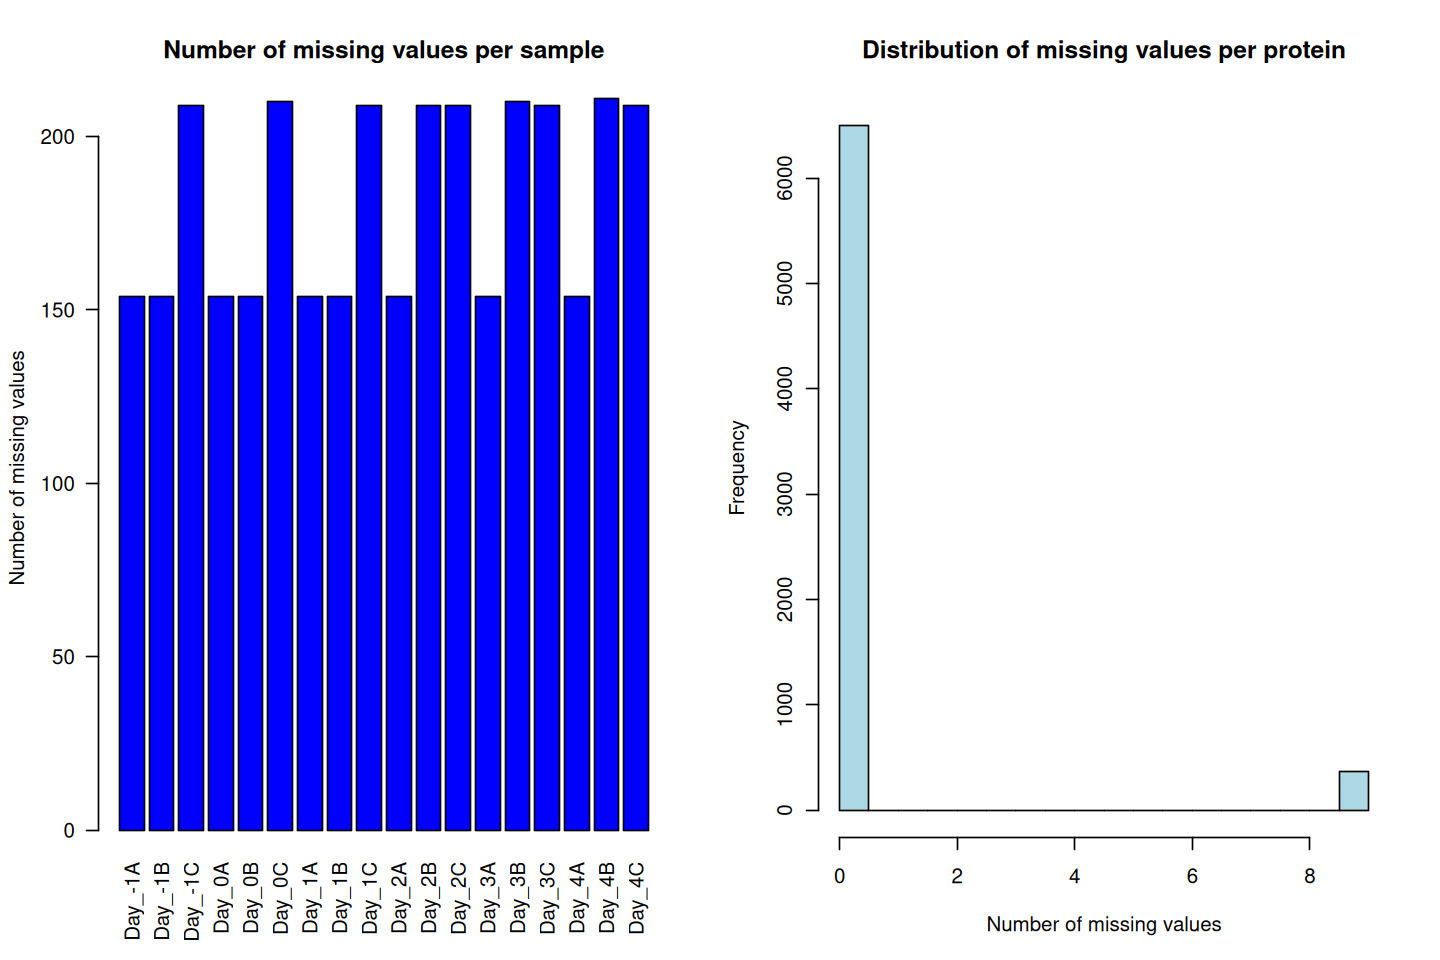

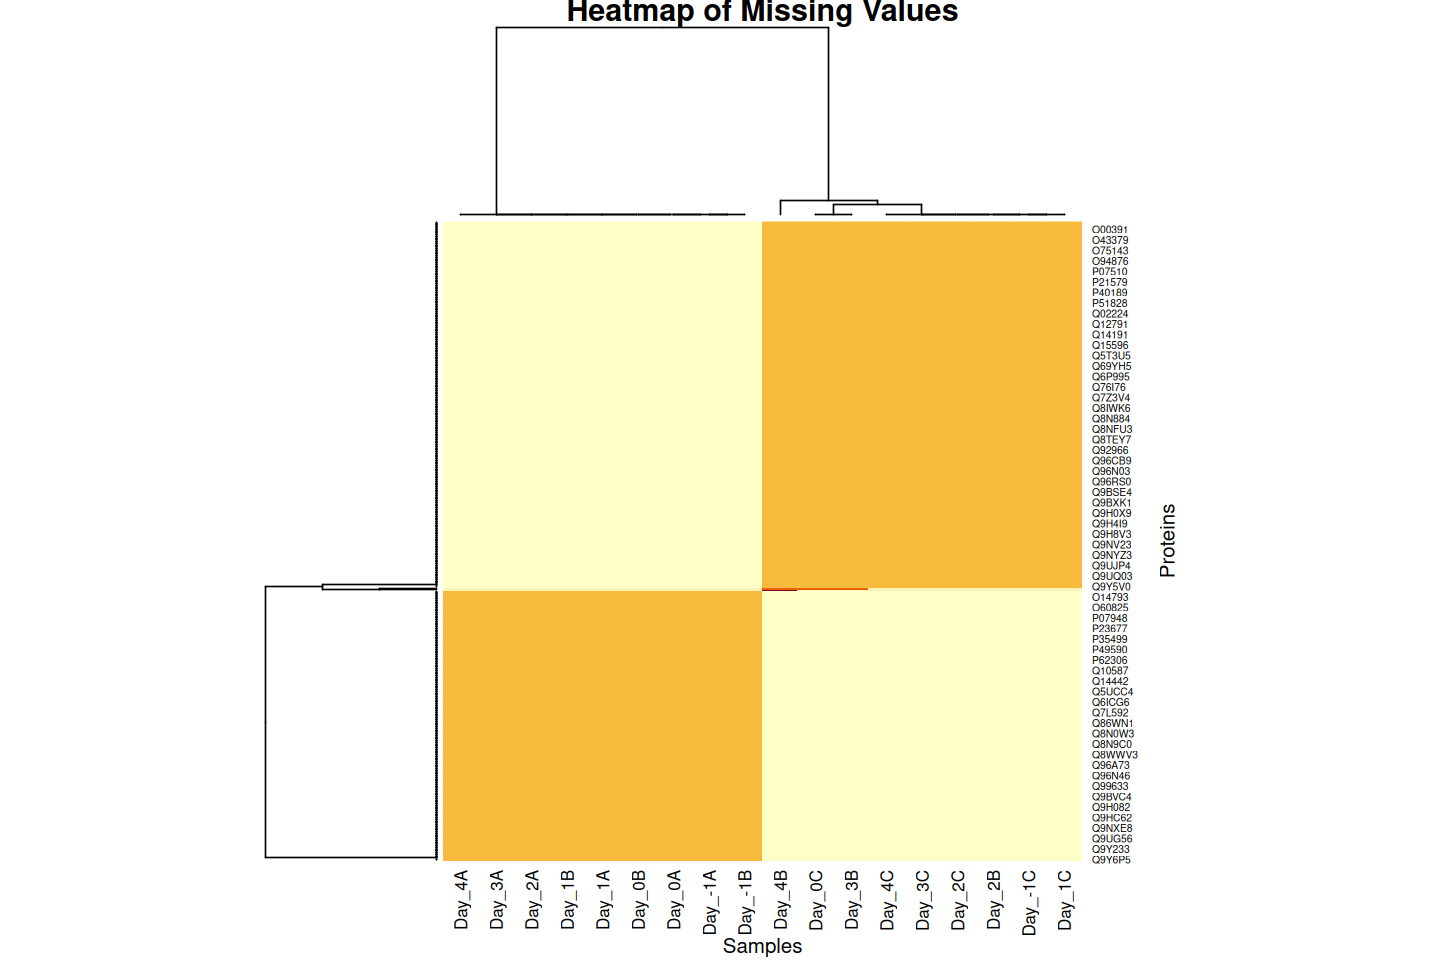

In [7]:
# Get the quantification columns
quant_table <- protein_table[, 6:ncol(protein_table)]
colnames(quant_table) <- paste0("Day_", rep(-1:4, each=3), rep(c("A","B","C"), times=6))

# Create a matrix indicating missing values
miss_matrix <- is.na(quant_table)

# Total number of missing values in the dataset
sum(miss_matrix)

# Number of missing values per sample
colSums(miss_matrix)

par(mfrow=c(1,2))
barplot(colSums(miss_matrix), main="Number of missing values per sample", xlab="", 
        ylab="Number of missing values", col="blue", las=2)

# Number of missing values per protein
hist(rowSums(miss_matrix), main="Distribution of missing values per protein", xlab="Number of missing values", 
     ylab="Frequency", col="lightblue", breaks=20)

# Creating a heatmap of missing values
only_miss_matrix <- miss_matrix[rowSums(miss_matrix) > 0, ]  # Keep only proteins with at least one missing value
mode(only_miss_matrix) <- "numeric"  # Convert logical to numeric for heatmap
heatmap(only_miss_matrix, main="Heatmap of Missing Values", xlab="Samples", ylab="Proteins")





## Understanding missing value patterns

#### Add your answers here
(double-click here to edit the cell)

❔ Question I:  <ins>What is the predominant reason for the observed missing value distribution? Is it expected?</ins>

_Answer_

❔ Question II:  <ins>What could be the reason for getting missing values? Are they missing by random or by low abundance? Or both?</ins>

_Answer_

❔ Question II:  <ins>How would you impute these missing values?</ins>

_Answer_




## Can we check for the impact of abundance levels?

As you can see in the values of the data (we will make a violin plot below), they are arranged around 0, thus showing that they have been log-transformed already, and adjusted to a common channel to allow comparison across the two TMT runs. Therefore, this type of data acquisition (TMT) does only allow relative quantification.

We still can get a rough idea of the amount of protein from the number of quantified peptides. The emphasis here is on "rough" as proteins have different numbers of tryptic peptides. However, we can still assess whether this quantities are related to missingness, assuming that the general levels of these proteins might be low or high for all samples. 

👨‍💻 In the following, plot the distributions for the different samples and compare the measured peptide number for protein with and without missing values.

### Interpreting abundance vs. missingness

- **Violin plot:** Confirm that medians line up close to zero, large offsets imply additional normalization is required.
- **Peptide-count curves:** Red vs. blue traces highlight how protein abundance changes for proteins with and without missing values.

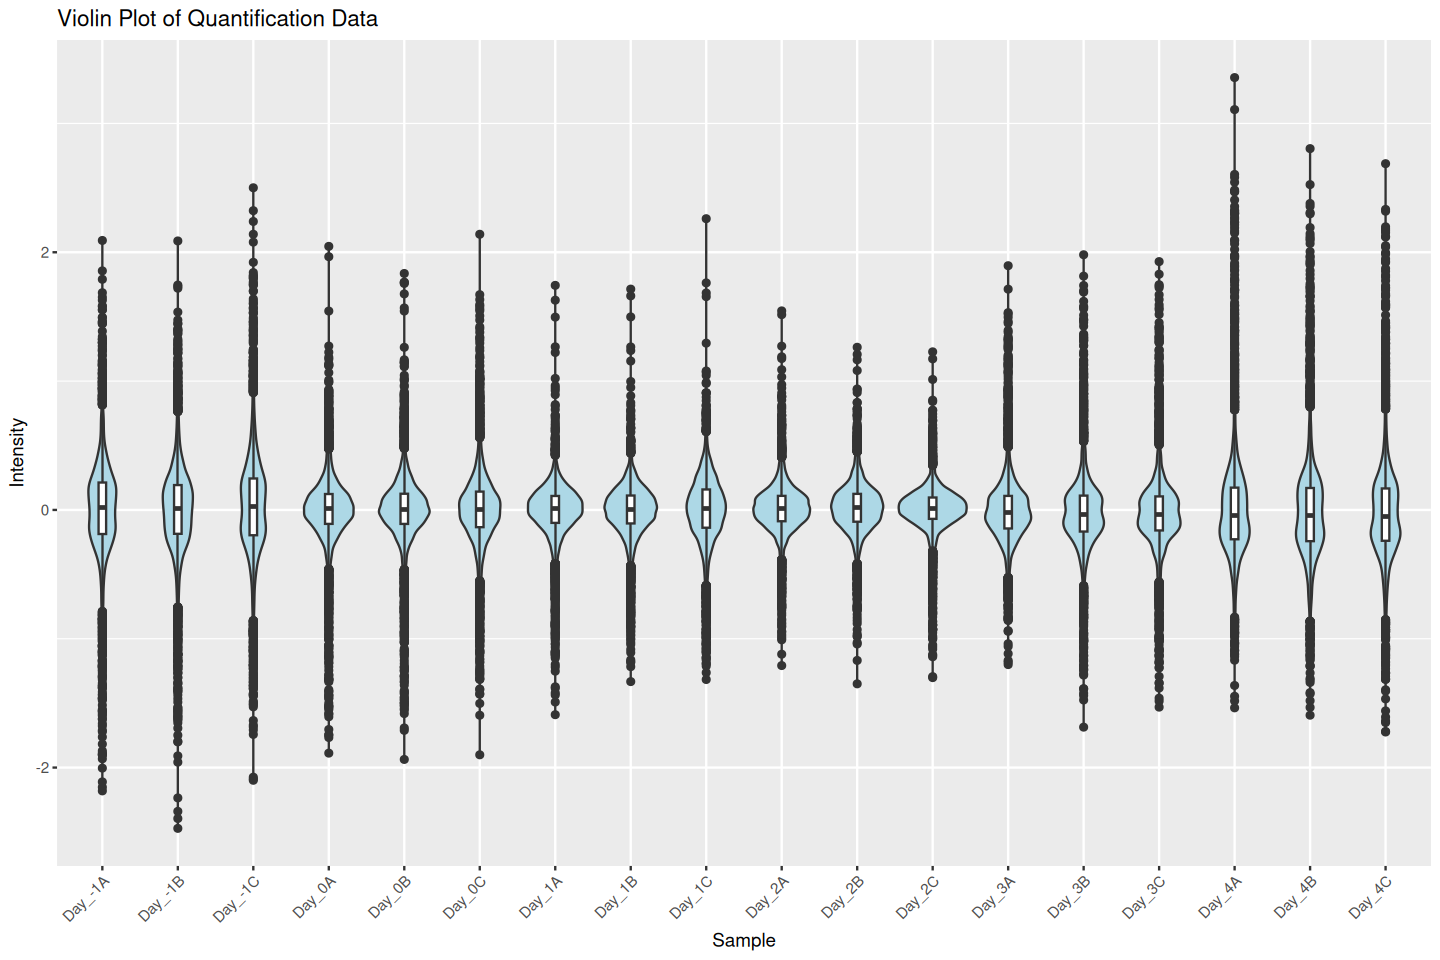

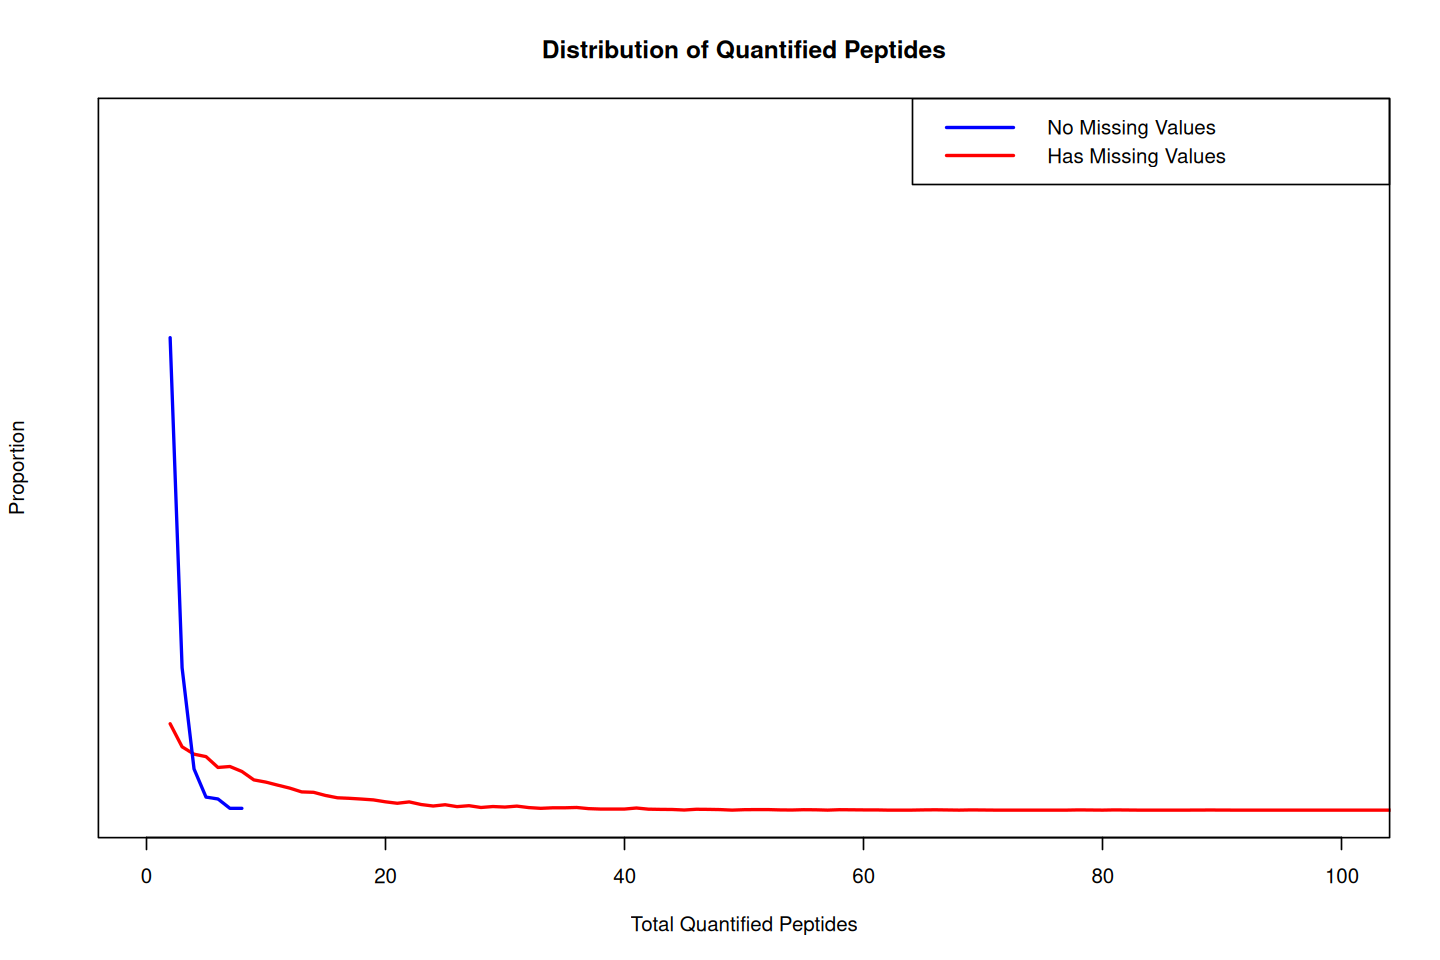

In [8]:
# Create violin plots of the quantification data
quant_data <- as.matrix(quant_table)
quant_data_melt <- reshape2::melt(quant_data, varnames=c("Protein", "Sample"), value.name="Intensity")
ggplot(quant_data_melt, aes(x=Sample, y=Intensity)) +
  geom_violin(fill="lightblue", na.rm=TRUE) + geom_boxplot(width=0.1, fill="white", na.rm=TRUE) +
  labs(title="Violin Plot of Quantification Data", x="Sample", y="Intensity") +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))  

# Comparing distribution of quantified peptides for protein with and without missing values
quant_pep <- data.frame(protein_table$Total.quantified.peptides, rowSums(miss_matrix) > 0)
colnames(quant_pep) <- c("TotalQuantifiedPeptides", "HasMissingValues")

# Count missing values for each number of quantified peptides
counts_no_miss <- table(quant_pep$TotalQuantifiedPeptides[quant_pep$HasMissingValues == 0])
counts_miss <- table(quant_pep$TotalQuantifiedPeptides[quant_pep$HasMissingValues > 0])

# Plotting the distributions
plot(as.numeric(names(counts_no_miss)), counts_no_miss/sum(counts_no_miss), type="l", col="red", 
  lwd=2, xlab="Total Quantified Peptides", ylab="Proportion", 
  xlim=c(0,100), ylim = c(0,1), main="Distribution of Quantified Peptides")
lines(as.numeric(names(counts_miss)), counts_miss/sum(counts_miss), col="blue", lwd=2)
legend("topright", legend=c("No Missing Values", "Has Missing Values"), col=c("blue", "red"), lwd=2)

## Understanding general quantitative trends

#### Add your answers here
(double-click here to edit the cell)

❔ Question I:  <ins>The data spread is different for the different days along the differentiation time line. Why could that be?</ins>

_Answer_

❔ Question II:  <ins>Are low abundant proteins more likely to be missing?</ins>

_Answer_

❔ Question II:  <ins>Would you still trust to have imputed values? What would be your procedure to impute?</ins>

_Answer_




## Normalization

As we saw in the boxplot, the median levels are slightly different. 

👨‍💻 Correct this by subtracting the medians to ensure that the samples are more comparable.

💡Why median centering?  
- Median subtraction keeps relative within-channel differences intact while aligning overall levels across runs.
- Medians are robust against extreme outliers

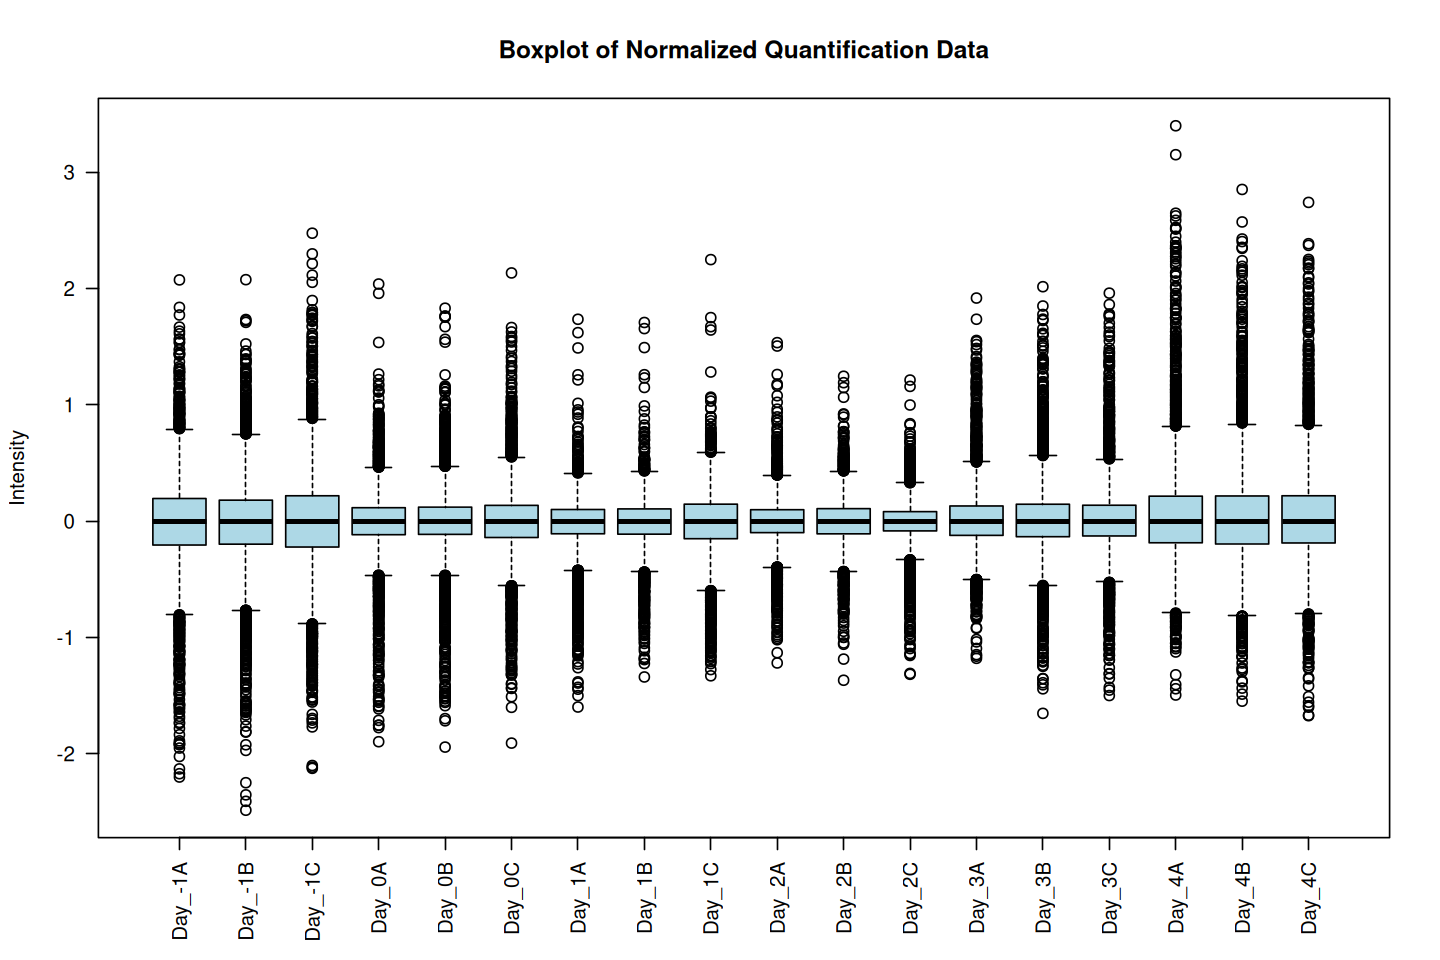

In [9]:
# Simple median normalization
medians <- apply(quant_table, 2, median, na.rm=TRUE)
quant_table_norm <- t(t(quant_table) - medians)

boxplot(quant_table_norm, main="Boxplot of Normalized Quantification Data", xlab="", ylab="Intensity", 
        col="lightblue", las=2)

## Finding differentially regulated proteins

We will run statistical tests to find out which proteins show differential regulation between the different time points. For that, we will use the limma test which is also suitable for data with low numbers of replicates and missing values (see also [ref](https://pubmed.ncbi.nlm.nih.gov/23875961/)).

💡 Statistical tests generally compare 2 different experimental conditions (here time points). When having many different condition, clustering is a good option to detect groups of features with similar quantitative behavior.

👨‍💻 We will compare day 0 versus day 4, i.e. satellite cells versus muscle cells.

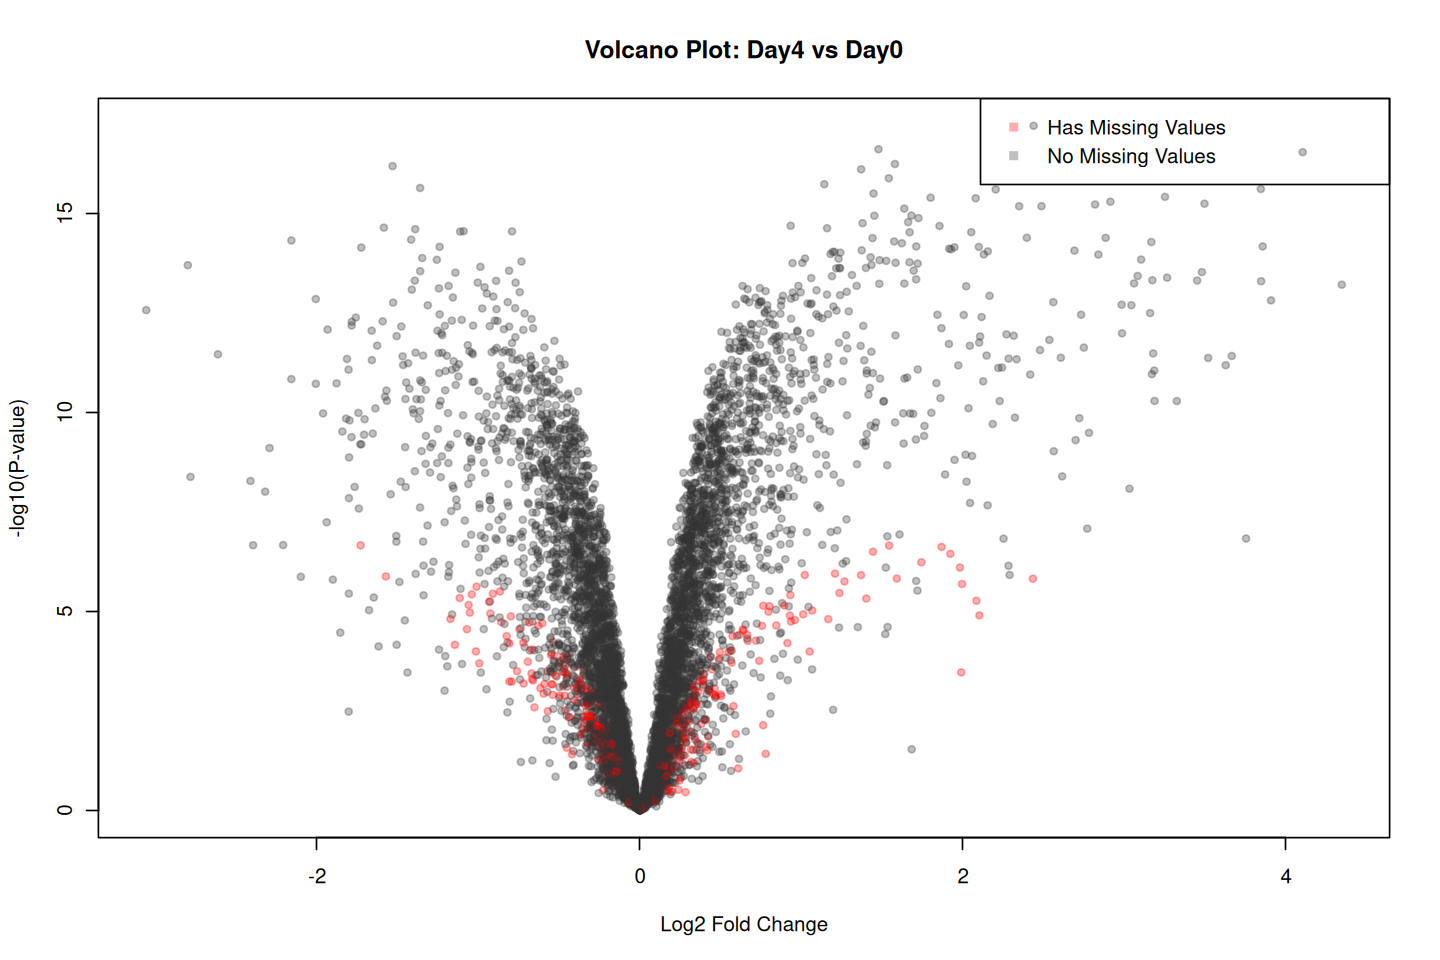

In [12]:
## Running a statistical test (limma)

# Setting experimental design
sample_info <- data.frame(
  sample = colnames(quant_table_norm),
  timepoint = factor(rep(c("Daym1","Day0","Day1","Day2","Day3","Day4")
                     , each = 3))
)

design <- model.matrix(~ 0 + timepoint, data = sample_info)
colnames(design) <- levels(sample_info$timepoint)

# Fitting the linear model and performing statistical testing
fit <- lmFit(quant_table_norm, design)

# Define comparisons of interest (e.g., Day4 vs Day0)
cont <- makeContrasts(
  Day4_vs_Day0 = Day4 - Day0,
  levels = design
)

# Fit contrasts and apply empirical Bayes moderation
fit2 <- contrasts.fit(fit, cont)
fit2 <- eBayes(fit2)  

# Make volcano plot for the comparison of interest coloring by missing values
volcanoplot(fit2, coef="Day4_vs_Day0", main="Volcano Plot: Day4 vs Day0", pch=20, cex=1, 
col=ifelse(rowSums(miss_matrix) > 0, "#FF000050", "#33333350"))
legend("topright", legend=c("Has Missing Values", "No Missing Values"), col=c("#FF000050", "#33333350"), pch=15)


💡 Interpreting the limma output

- Use `str(fit2)` or `summary(decideTests(fit2))` to confirm how many proteins change per contrast.
- In the volcano plot, red points denote highlight entries without complete quantification across all samples.
- Record the log₂ fold-change and adjusted p-value cutoffs you adopt; you can compare them when validating results in PolySTest.

## Statistical considerations

#### Add your answers here
(double-click here to edit the cell)

❔ Question I:  <ins>Why do we use logarithms for the x- and y-axes? And why logarithms with different bases?</ins>

_Answer_

❔ Question II:  <ins>There seem to be proteins with very high fold-change to the right? What does this biologically mean?</ins>

_Answer_

❔ Question II:  <ins>Why is the center of the volcano empty?</ins>

_Answer_

❔ Question IV:  <ins>What is different between the results for proteins with missing values? Think about statistical power.</ins>

_Answer_



## Which proteins are there

We will have a quick look into the most changing proteins. A more thorough and adequate analysis would be through pathway enrichement analysis. 

💡 Note that you still need to distinguish between up-regulated and down-regulated proteins. 

You will see that some of the proteins are clearly proteins that are typical for muscles.

In [ ]:
# Most significant proteins in the comparison of interest
res_day4 <- topTable(fit2, coef = "Day4_vs_Day0")
head(res_day4, 10)  

protein_table[rownames(head(res_day4, 10)), c("Gene.Name", "Protein.Name")]


## PolySTest

You can run statistical testing also with more user-friendly applications like PolySTest (see also [PolySTest paper](https://pubmed.ncbi.nlm.nih.gov/32424025/)). This is a web application but is also available as Bioconductor R package to embed the statistical testing in an R script running an analysis workflow.  

PolySTest joins different statistical tests, also limma, to provide more robust solutions. It also includes a specific Miss test to deal with sparse data where missing values are a problem, thus avoiding imputations that can falsely increase the statistical power.

👨‍💻 There are several possibilities to run the Shiny App:

a) Download the docker image `docker pull veitveit/polystest` and run  it using `docker run -p3838:3838 veitveit/polystest`. You can access the app via localhost:3838 in your browser afterwards

b) Run it on the server (here we have a max. of 5 sessions a time): http://computproteomics.bmb.sdu.dk/app_direct/PolySTest

c) install the R package: `BiocManager::install("PolySTest")`

👨‍💻 First play with the example and become familiar with the app

👨‍💻 Then upload the csv-file of the protein table and run the statistical tests.

👨‍💻 Inspect the output and try to understand what they show.


## Statistical considerations

#### Add your answers here
(double-click here to edit the cell)

❔ Question I:  <ins>Which FDR threshold would you choose and why?</ins>

_Answer_

❔ Question II:  <ins>What needs to be taken into account when joining different tests?</ins>

_Answer_

❔ Question II:  <ins>What would be your next steps?</ins>

_Answer_


